In this assignment, you are required to implement the following morphological operations from scratch (without using built-in OpenCV functions for these operations):
  Erosion  
  Dilation  
  Opening  
  Closing  
You will verify your implementation using the attached images and compare the results with
the corresponding built-in OpenCV functions. Additionally, write down any observations regarding the differences in results.


#Submission Requirements:  
#A Python script containing :
Your implementation of the required operations.

Comparisons with the built-in OpenCV functions (using the same attached images).

A brief written summary of your observations about the differences between your implementation and the OpenCV functions.

#Notes :
Ensure that your code is well-structured and commented.

# Morphological Operations Implementation

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Erosion  

In [ ]:
def erode_image(image, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    pad_size = kernel_size//2
    padded_image = np.pad(image, pad_size, mode='constant',constant_values=0)

    eroded_image = np.zeros_like(image)  # Initialize output image

    # if all pixels under kernel are 255, keep 255 else 0
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_image[i:i + kernel_size, j:j + kernel_size]
            if np.all(region == 255):  # all pixels under kernel must be white
                eroded_image[i, j] = 255
            else:
                eroded_image[i, j] = 0

    return eroded_image


# Dilation

In [ ]:
def dilate_image(image, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    pad_size = kernel_size// 2
    padded_image = np.pad(image, pad_size, mode='constant', constant_values=0)
    dilated_image = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_image[i:i + kernel_size, j:j + kernel_size]
            if np.any(region == 255):
                dilated_image[i, j] = 255

    return dilated_image

# Opening  

In [ ]:
def opening(image, kernel_size=3):
    """Performs opening (erosion followed by dilation)."""
    return dilate_image(erode_image(image, kernel_size), kernel_size)


# Closing

In [ ]:
def closing(image, kernel_size=3):
    """Performs closing (dilation followed by erosion)."""
    return erode_image(dilate_image(image, kernel_size), kernel_size)



---



In [ ]:
def compare_morphological_operations(image_file):
    for file in image_file:
        image = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
        binary_image = binarize_image(image)
        kernel = np.ones((5, 5), np.uint8)

        # OpenCV operations
        built_in_erosion = cv2.erode(binary_image, kernel, iterations=1)
        built_in_dilation =cv2.dilate(binary_image, kernel, iterations=1)
        built_in_opening =cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)
        built_in_closing= cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)
        # From scratch
        custom_erosion = erode_image(binary_image, 5)
        custom_dilation = dilate_image(binary_image, 5)
        custom_opening = opening(binary_image, 5)
        custom_closing = closing(binary_image, 5)

        titles = ["Erosion (Custom)", "Erosion (OpenCV)","Dilation (Custom)", "Dilation (OpenCV)",
                  "Opening (Custom)", "Opening (OpenCV)","Closing (Custom)", "Closing (OpenCV)"]

        images = [custom_erosion, built_in_erosion,custom_dilation, built_in_dilation,
                  custom_opening, built_in_opening,custom_closing, built_in_closing]

        plt.figure(figsize=(10, 8))
        plt.suptitle(f"Comparing Morphological Operations: {file}", fontsize=14)

        for i in range(len(images)):
            plt.subplot(4, 2, i+1)
            plt.imshow(images[i], cmap='gray')
            plt.title(titles[i])
            plt.axis("off")

        plt.tight_layout()
        plt.show()



In [ ]:
def binarize_image(image, threshold=128):
    binary_image = np.where(image >= threshold, 255, 0).astype(np.uint8)
    return binary_image



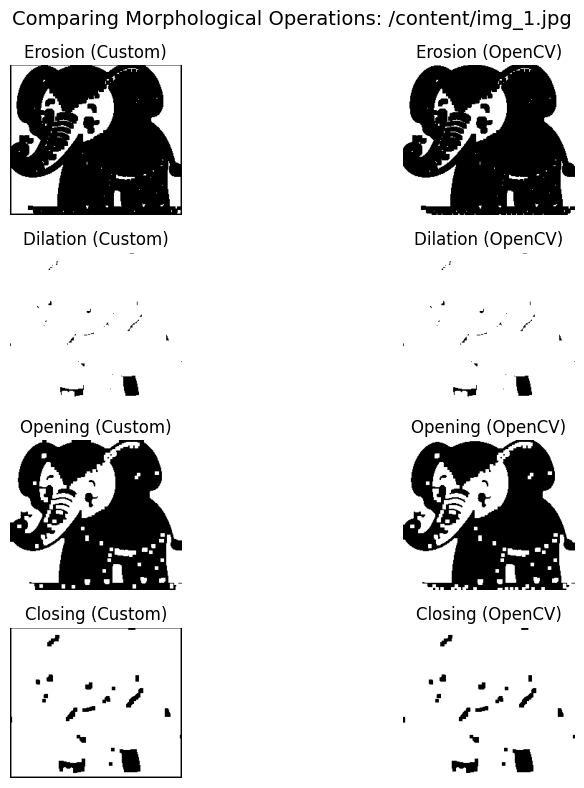

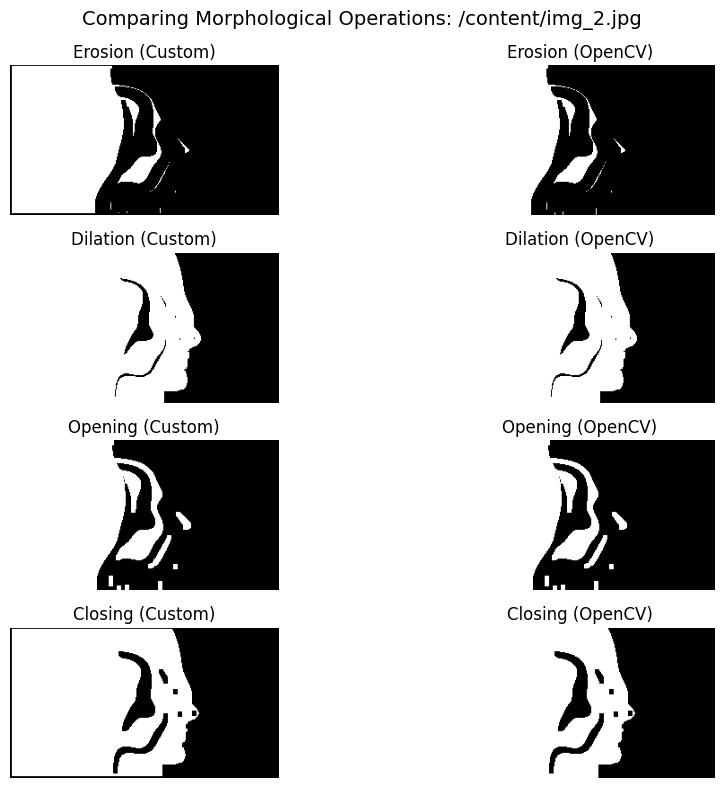

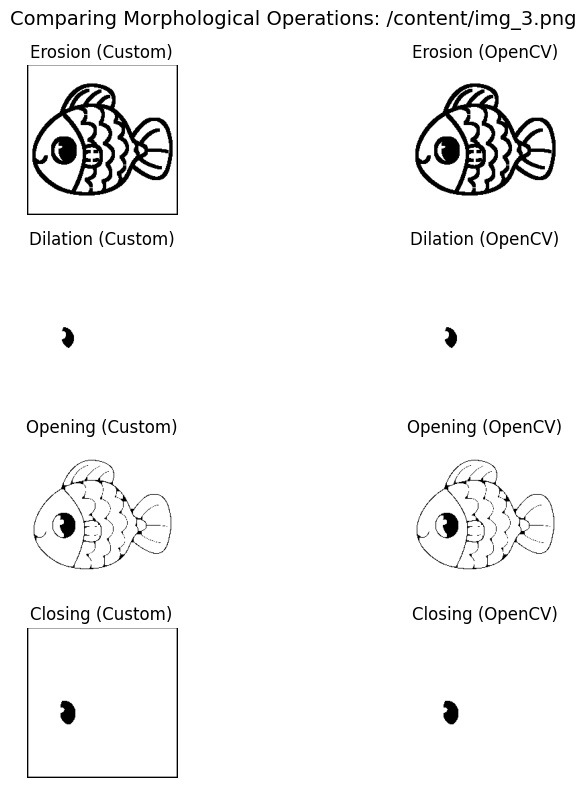

In [ ]:
image_file = ['/content/img_1.jpg','/content/img_2.jpg','/content/img_3.png']
compare_morphological_operations(image_file)


# The output using cv2 libary is very similar to from scratch implementation

#custom seems more eroded that opencv

#There is more noise for custom dilation comparing to opencv implementation